In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
water,18.02,1.2047,2.801457,353.94,1,1
propylamine,59.11,2.4539,3.5347,250.52,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,propylamine,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propylamine,H,propylamine,e,1028.1,0.022674
water,H,water,e,2425.67,0.045
propylamine,H,water,e,1726.885,0.031727997
propylamine,e,water,H,1726.885,0.031727997
"""

model = PCSAFT(["water", "propylamine"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[353.94 300.7512205808648; 300.7512205808648 250.52]
[2.8014570000000003e-10 3.1680785e-10; 3.1680785e-10 3.5347e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_water::Float64)
    P = 101325 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    T = bub[1]
    y = bub[4][1]
    return T
end

function vle_y(model::EoSModel, x_water::Float64)
    P = 101325 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [4]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 80.,
        :upper   => 500.0,
        :guess   => 179.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 500.0, :param => :epsilon, :indices => (1, 2), :guess => 179.0, :lower => 80.0)

In [5]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_propylamine.csv")
fix_line_endings("vley_propylamine.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_propylamine.csv"
        "vley_propylamine.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_propylamine.csv
Fixed: vley_propylamine.csv
Initial objective value: 73.4217375039329


In [6]:
method = ECA(; options = Options(iterations = 1000000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([331.8496111831492], PCSAFT{BasicIdeal, Float64}("water", "propylamine"))

In [7]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[353.94 331.8496111831492; 331.8496111831492 250.52]
[2.8014570000000003e-10 3.1680785e-10; 3.1680785e-10 3.5347e-10]
kij = -0.11443639911965708


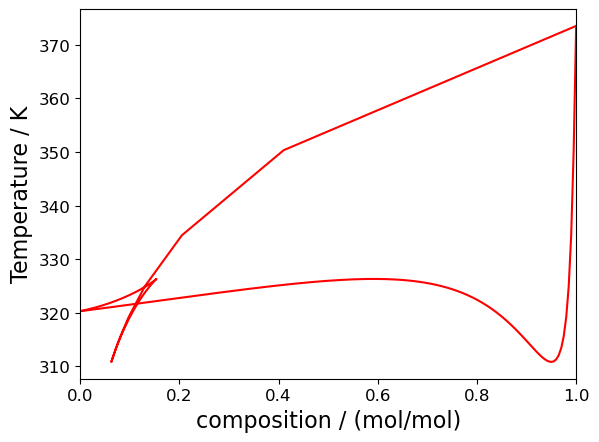

([300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0], PyCall.PyObject[PyObject Text(0, 300.0, '300'), PyObject Text(0, 310.0, '310'), PyObject Text(0, 320.0, '320'), PyObject Text(0, 330.0, '330'), PyObject Text(0, 340.0, '340'), PyObject Text(0, 350.0, '350'), PyObject Text(0, 360.0, '360'), PyObject Text(0, 370.0, '370'), PyObject Text(0, 380.0, '380')])

In [8]:
import PyPlot; const plt = PyPlot
using Clapeyron

N    = 201
p    = 101325

x    = LinRange(0., 1.,  N)
T    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_temperature(model, p, [x[i], 1-x[i]])
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_temperature(model, p, [x[i], 1-x[i]]; v0 = v0)
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),bub[4])
    end
end

plt.clf()
plt.plot(x, T, color="red")
plt.plot(y, T, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Temperature / K",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
     

In [9]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [10]:
aard_p   = calculate_AAD(model_opt, "vlep_propylamine.csv", vle_p)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: vlep_propylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1910      324.936500    324.234416    0.2161  
0.2480      326.336100    325.389677    0.2900  
0.3450      328.735400    327.437723    0.3947  
0.4380      332.434500    329.604754    0.8512  
0.5570      336.633700    332.973658    1.0872  
0.6350      340.232900    335.863044    1.2844  
0.7470      345.331400    341.909349    0.9909  
0.8160      348.230500    347.653833    0.1656  
AARD = 0.6600%


0.6600269224211421

In [11]:
aard_p   = calculate_AAD(model_opt, "vley_propylamine.csv", vle_y)


=== AAD: vley_propylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1910      0.036000      0.039109      8.6374  
0.2480      0.050000      0.049543      0.9150  
0.3450      0.081000      0.067588      16.5578 
0.4380      0.112000      0.086604      22.6753 
0.5570      0.161000      0.117242      27.1789 
0.6350      0.204000      0.145599      28.6279 
0.7470      0.289000      0.214562      25.7572 
0.8160      0.349000      0.296272      15.1084 
AARD = 18.1822%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


18.182238056107067